In [ ]:
import librosa 
import numpy as np
import matplotlib.pyplot as plt

#Load Audio (Librosa automatically converts to mono)
audio, fs = librosa.load("traffic.mp3", sr=None)

print("Sampling Rate: ",fs)
print("Number of Samples: ", len(audio))


Sampling Rate:  44100
Number of Samples:  557568


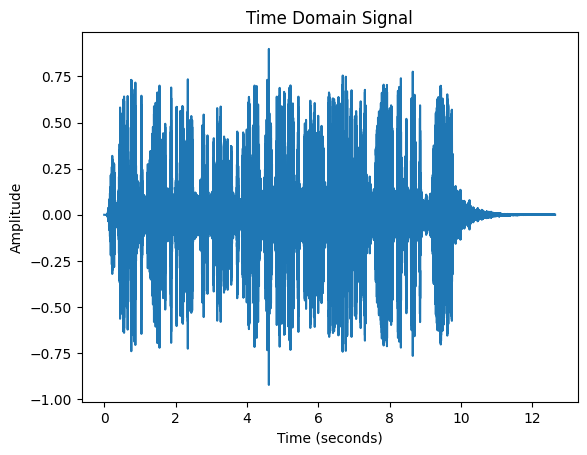

In [12]:
t = np.arange(len(audio)) / fs

plt.figure()
plt.plot(t, audio)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Time Domain Signal")
plt.show()

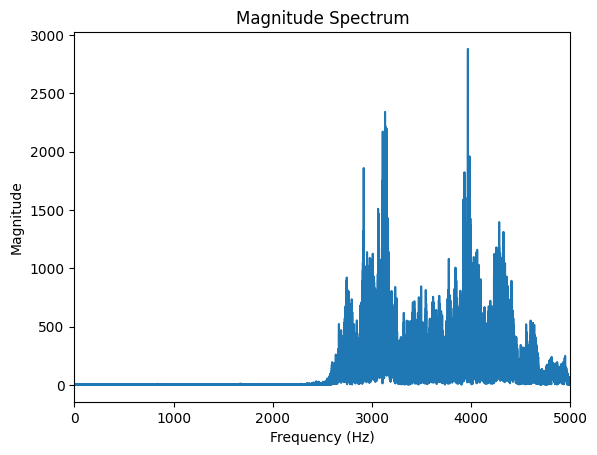

In [13]:
N = len(audio)
X = np.fft.fft(audio)
f = np.fft.fftfreq(N, 1/fs)

positive = f > 0

plt.figure()
plt.plot(f[positive], np.abs(X[positive]))
plt.xlim(0, 5000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Magnitude Spectrum")
plt.show()

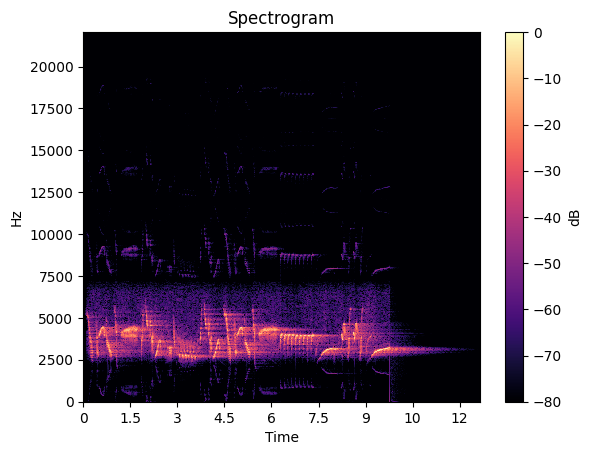

In [14]:
D = librosa.stft(audio)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure()
librosa.display.specshow(S_db, sr=fs, x_axis='time', y_axis='hz')
plt.colorbar(label='dB')
plt.title("Spectrogram")
plt.show()

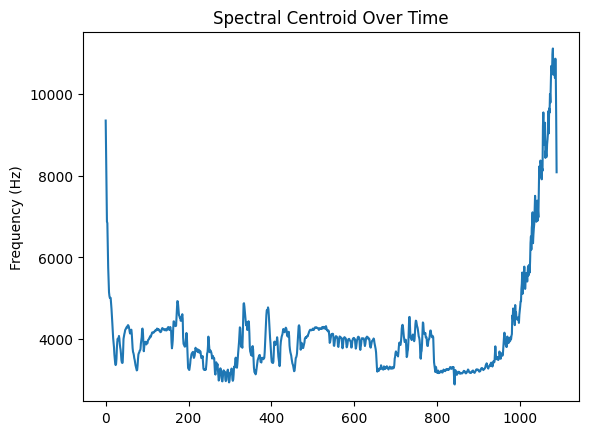

In [15]:
centroid = librosa.feature.spectral_centroid(y=audio, sr=fs)

plt.figure()
plt.plot(centroid.T)
plt.title("Spectral Centroid Over Time")
plt.ylabel("Frequency (Hz)")
plt.show()

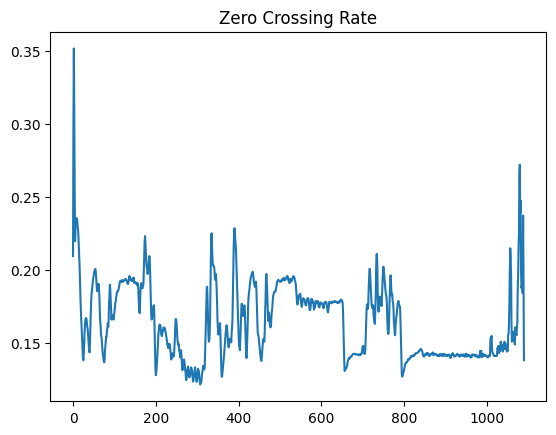

In [16]:
zcr = librosa.feature.zero_crossing_rate(audio)

plt.figure()
plt.plot(zcr.T)
plt.title("Zero Crossing Rate")
plt.show()

In [17]:
# Dominant frequency
audio_short = audio[:2*fs] 
X = np.fft.rfft(audio_short)
freqs = np.fft.rfftfreq(len(audio_short), 1/fs)

dominant_freq = freqs[np.argmax(np.abs(X))]
print("Dominant Frequency:", dominant_freq)

# Mean spectral centroid
mean_centroid = np.mean(centroid)

print("Average Spectral Centroid:", mean_centroid)

# Mean zero crossing rate
mean_zcr = np.mean(zcr)

print("Average Zero Crossing Rate:", mean_zcr)

Dominant Frequency: 4325.0
Average Spectral Centroid: 4131.309368525011
Average Zero Crossing Rate: 0.16458393061926604
